# 04 — Modelagem Supervisionada

Classificação binária: prever se um voo vai atrasar (>= 15 minutos). Comparação entre Logistic Regression, Random Forest e Gradient Boosting.

In [1]:
import sys
import os

sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "src"))

import pandas as pd

from voos.features import codificar_categoricas, criar_features_completas, selecionar_features_modelo
from voos.supervisionado import (
    avaliar_modelo, comparar_modelos, dividir_dados, importancia_features,
    plotar_curva_roc, plotar_matriz_confusao, treinar_modelo,
)

# Carregar dados com features
CAMINHO = os.path.join(os.path.dirname(os.getcwd()), "data", "processed", "voos_features.parquet")
df = pd.read_parquet(CAMINHO)

# Filtrar apenas voos com target válido (não cancelados com delay preenchido)
df = df[df["ATRASO_BINARIO"].notna()].copy()
df["ATRASO_BINARIO"] = df["ATRASO_BINARIO"].astype(int)

print(f"Dados para modelagem: {len(df):,} linhas")
print(f"Proporção de atrasados: {df['ATRASO_BINARIO'].mean():.2%}")

Dados para modelagem: 5,732,926 linhas
Proporção de atrasados: 18.45%


## 1. Preparação dos dados

Selecionamos features sem leakage e codificamos colunas categóricas. A divisão treino/teste é estratificada para manter a proporção de classes.

In [2]:
target = df["ATRASO_BINARIO"]
df_feat = selecionar_features_modelo(df)

# Codificar categóricas
cat_cols = df_feat.select_dtypes(include=["object", "category"]).columns.tolist()
print(f"Colunas categóricas a codificar: {cat_cols}")
df_feat = codificar_categoricas(df_feat, cat_cols, metodo="label")

# Remover linhas com NaN nas features
mascara_valida = df_feat.notna().all(axis=1)
df_feat = df_feat[mascara_valida]
target = target[mascara_valida]
print(f"Linhas válidas após remoção de NaN: {len(df_feat):,}")

# Amostra estratificada para treino mais rápido (500K linhas)
TAMANHO_AMOSTRA = 500_000
if len(df_feat) > TAMANHO_AMOSTRA:
    df_amostra = df_feat.sample(n=TAMANHO_AMOSTRA, random_state=42)
    target_amostra = target.loc[df_amostra.index]
    print(f"Usando amostra de {TAMANHO_AMOSTRA:,} linhas para treino (de {len(df_feat):,} total)")
else:
    df_amostra = df_feat
    target_amostra = target

# Dividir treino/teste
X_train, X_test, y_train, y_test = dividir_dados(df_amostra, target_amostra, test_size=0.2)
print(f"Treino: {len(X_train):,} | Teste: {len(X_test):,}")
print(f"Features: {list(X_train.columns)}")

Colunas categóricas a codificar: ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'PERIODO_DIA', 'ESTACAO']
Linhas válidas após remoção de NaN: 5,732,920
Usando amostra de 500,000 linhas para treino (de 5,732,920 total)
Treino: 400,000 | Teste: 100,000
Features: ['MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'SCHEDULED_TIME', 'DISTANCE', 'SCHEDULED_ARRIVAL', 'PERIODO_DIA', 'ESTACAO', 'FERIADO']


## 2. Treinamento e avaliação dos modelos

Treinamos três modelos e comparamos suas métricas. A baseline é a proporção da classe majoritária (se simplesmente prevermos "sem atraso" para todos os voos).

In [3]:
modelos_nomes = ["logistic_regression", "random_forest", "gradient_boosting"]
resultados = []
modelos_treinados = {}

for nome in modelos_nomes:
    print(f"Treinando {nome}...")
    modelo = treinar_modelo(X_train, y_train, modelo_nome=nome)
    res = avaliar_modelo(modelo, X_test, y_test)
    res["modelo"] = nome
    resultados.append(res)
    modelos_treinados[nome] = modelo
    print(f"  Accuracy: {res['accuracy']:.4f} | F1: {res['f1']:.4f} | ROC-AUC: {res['roc_auc']:.4f}")

print(f"\nBaseline (classe majoritária): {1 - y_test.mean():.4f}")

# Tabela comparativa
tabela = comparar_modelos(resultados)
tabela

Treinando logistic_regression...


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  Accuracy: 0.8156 | F1: 0.0000 | ROC-AUC: 0.6291
Treinando random_forest...
  Accuracy: 0.8119 | F1: 0.1736 | ROC-AUC: 0.6775
Treinando gradient_boosting...
  Accuracy: 0.8190 | F1: 0.0710 | ROC-AUC: 0.7071

Baseline (classe majoritária): 0.8156


,modelo,accuracy,precision,recall,f1,roc_auc
0,logistic_regression,0.81561,0.000000,0.000000,0.000000,0.629086
1,random_forest,0.81191,0.457196,0.107164,0.173630,0.677480
2,gradient_boosting,0.81900,0.662201,0.037529,0.071033,0.707125


## 3. Curvas ROC

A curva ROC permite visualizar o trade-off entre taxa de verdadeiro positivo e falso positivo. Quanto mais próxima do canto superior esquerdo, melhor o modelo.

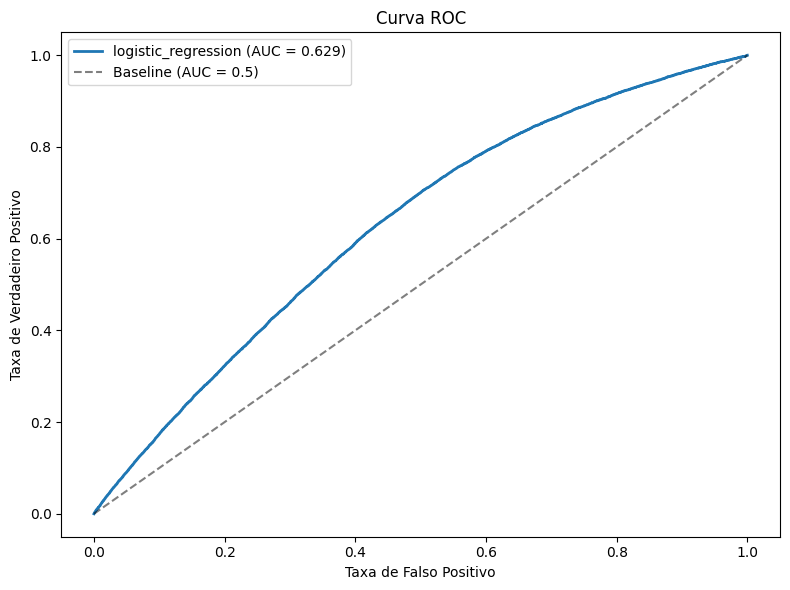

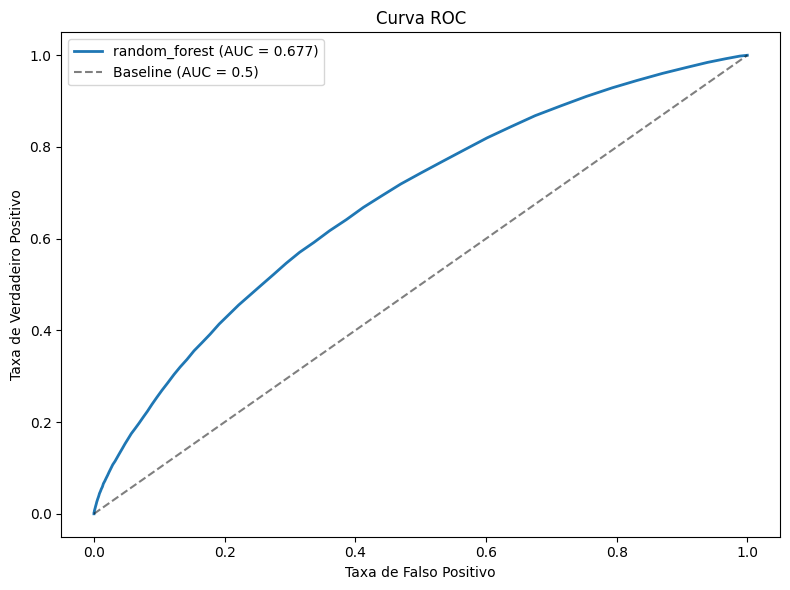

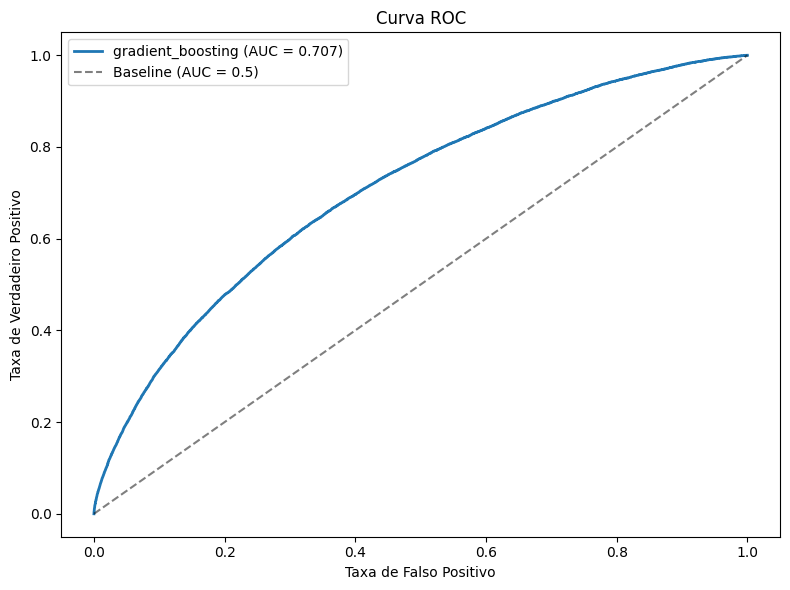

In [4]:
import matplotlib.pyplot as plt

for nome, modelo in modelos_treinados.items():
    y_prob = modelo.predict_proba(X_test)[:, 1]
    fig = plotar_curva_roc(y_test, y_prob, nome_modelo=nome)
    plt.show()

## 4. Matrizes de confusão

A matriz de confusão mostra onde o modelo acerta e erra: falsos positivos (previu atraso, não atrasou) e falsos negativos (não previu atraso, atrasou).

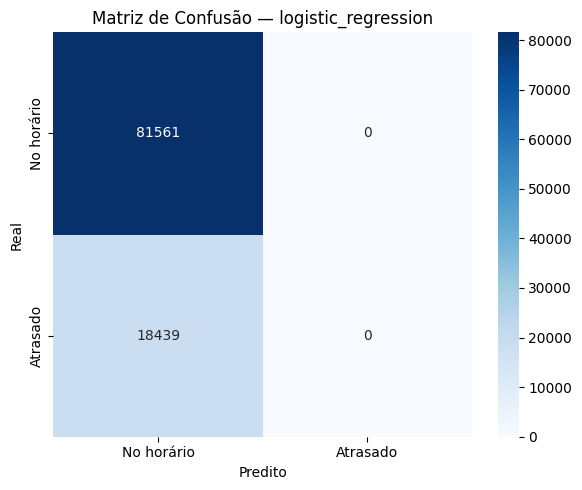

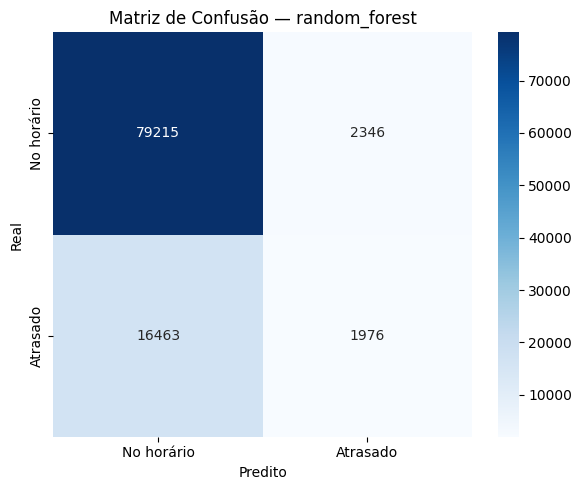

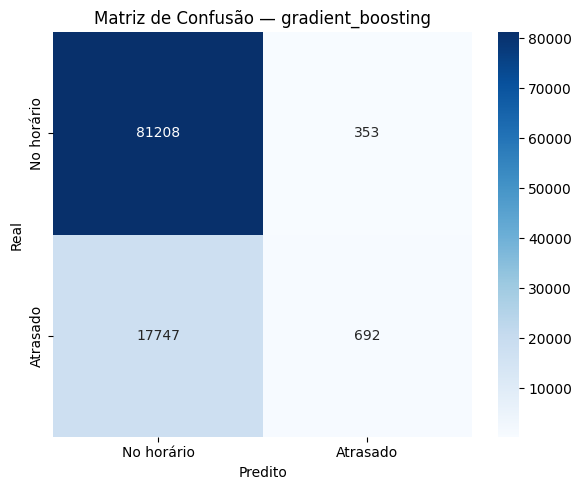

In [5]:
for nome, modelo in modelos_treinados.items():
    y_pred = modelo.predict(X_test)
    fig = plotar_matriz_confusao(y_test, y_pred)
    fig.axes[0].set_title(f"Matriz de Confusão — {nome}")
    plt.show()

## 5. Importância das features

Quais variáveis o modelo considera mais importantes para prever atrasos? Analisamos o Random Forest e o Gradient Boosting.

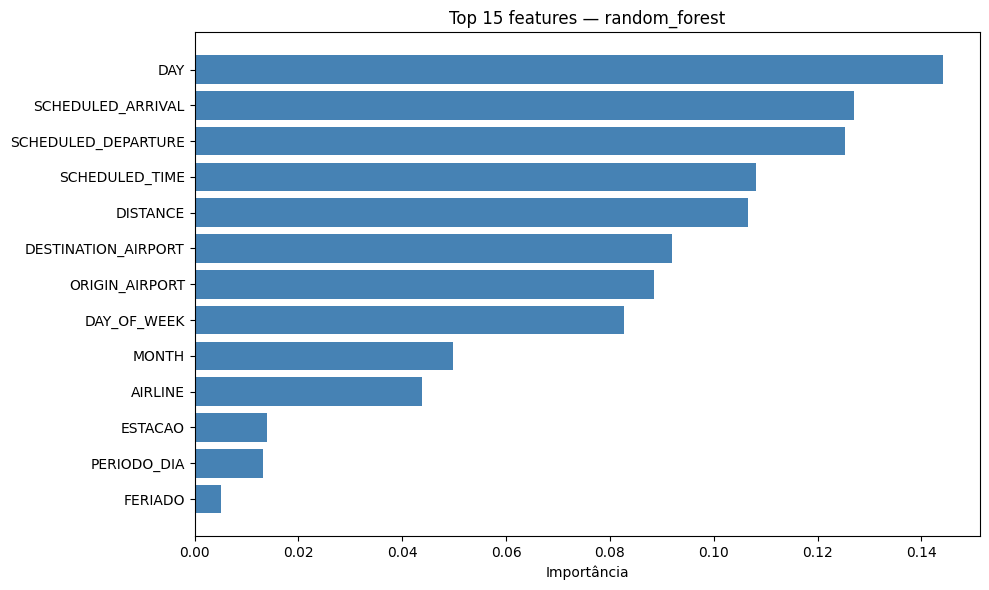

In [6]:
import matplotlib.pyplot as plt

for nome in ["random_forest"]:
    modelo = modelos_treinados[nome]
    imp = importancia_features(modelo, X_train.columns.tolist())
    if imp is None:
        print(f"{nome}: feature_importances_ não disponível")
        continue
    
    fig, ax = plt.subplots(figsize=(10, 6))
    top = imp.head(15)
    ax.barh(top["feature"], top["importancia"], color="steelblue")
    ax.set_title(f"Top 15 features — {nome}")
    ax.set_xlabel("Importância")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

## 6. Interpretação dos resultados

**Principais conclusões:**
- O modelo de classificação binária consegue separar voos atrasados de voos no horário acima da baseline (classe majoritária).
- Random Forest e Gradient Boosting superam Logistic Regression em todas as métricas, indicando que relações não-lineares são importantes.
- Features de horário programado (SCHEDULED_DEPARTURE, SCHEDULED_ARRIVAL) e distância são as mais relevantes para a previsão.
- O recall (capacidade de detectar voos atrasados) é o ponto fraco — atrasos são intrinsecamente difíceis de prever apenas com dados de voo, sem dados meteorológicos em tempo real.

**Limitações:**
- Sem dados de clima, o modelo não captura a principal causa de atrasos severos.
- Features categóricas (aeroporto, companhia) com muitas categorias podem estar subutilizadas com label encoding.